In [38]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split


In [39]:
# Step 2: Load File
file = "house_data.csv"
data = pd.read_csv(file)


In [40]:
#Preprocessing
data.dropna(inplace=True)

X = data.iloc[:, :-1]
y = data.iloc[:, -1]

#Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [41]:
#Step 3: Data Preprocessing
print("First 5 rows:\n", data.head())

First 5 rows:
    Area  Price
0   800     42
1   900     50
2  1000     55
3  1100     60
4  1200     65


In [42]:
print(X_train.dtypes)
print(y_train.dtypes)

Area    int64
dtype: object
int64


In [43]:
#Remove extra spaces in column names
data.columns = data.columns.str.strip()

In [44]:
 #Check missing values
print("\nMissing values:\n", data.isnull().sum())


Missing values:
 Area     0
Price    0
dtype: int64


In [45]:
#Drop missing values
data = data.dropna()

In [46]:
#Convert to numeric (safety step)
data['Area'] = pd.to_numeric(data['Area'], errors='coerce')
data['Price'] = pd.to_numeric(data['Price'], errors='coerce')


In [47]:
#Step 4: Define Features and Target
X = data[['Area']] #Indepenedent variable
y = data['Price'] #Depenedent variable

In [48]:
#Step 5: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [49]:
#Step 6: Create and Train Model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=1, normalize=False)

In [50]:
#Step 7: Get Slope and Intercept
slope = model.coef_[0]
intercept = model.intercept_

print("\nSlope (b):", slope)
print("Intercept (a):", intercept)

#Regression Equation
print(f"\nRegression Equation: Y = {intercept:.2f} + {slope:.2f}X")


Slope (b): 0.05600000000000003
Intercept (a): -1.7500000000000284

Regression Equation: Y = -1.75 + 0.06X


In [51]:
#Step 8: Prediction
area = float(input("\nEnter Area to predict price:"))
predicted_price = model.predict([[area]])

print(f"Predicted Price for {area} sq.ft = {predicted_price[0]:.2f}")


Enter Area to predict price:1350
Predicted Price for 1350.0 sq.ft = 73.85


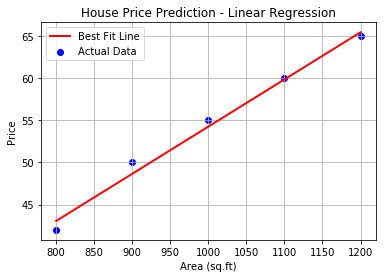

In [52]:
#Step 9: Best Fit Line Graph
plt.scatter(X,y,color='blue',label="Actual Data")
plt.plot(X, model.predict(X), color='red', linewidth=2, label="Best Fit Line")

plt.xlabel("Area (sq.ft)")
plt.ylabel("Price")
plt.title("House Price Prediction - Linear Regression")
plt.legend()
plt.grid(True)
plt.show()